# **Moteur de Simulation Monte Carlo et Évaluation du Risque (VaR & ES)**

**Contexte du Projet :** Étude comparative entre la simulation de Monte Carlo et le Machine Learning pour le calcul de la Value at Risk (VaR).

**Auteur :** ELMEHDI ES SADIKI

**Institution :** Caisse de Dépôt et de Gestion (CDG) - Digital Factory

---

### **Objectif de ce Notebook**
Ce deuxième notebook est consacré à l'approche économétrique classique de la gestion des risques : la **Simulation de Monte Carlo**. L'objectif est de modéliser l'incertitude des marchés financiers marocains en générant des milliers de trajectoires futures possibles pour l'indice MASI, afin d'en déduire une distribution de pertes théoriques.

Contrairement à la VaR Historique (calculée dans le Notebook 1) qui se contente de regarder le passé, le moteur de Monte Carlo utilise une **Équation Différentielle Stochastique (EDS)** pour simuler des futurs inédits.

**Les étapes clés réalisées ici sont :**
1. **Calibration des Paramètres :** Extraction du rendement espéré (Drift $\mu$) et de la volatilité ($\sigma$) à partir de notre *Train Set* (2005-2017).
2. **Génération Stochastique :** Implémentation vectorisée du Mouvement Brownien Géométrique (GBM) pour simuler 10 000 trajectoires de prix.
   $$ S_{t+\Delta t} = S_t \exp\left( \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} Z \right) $$
3. **Quantification du Risque :** Calcul de la Value at Risk (VaR) paramétrique et de l'Expected Shortfall (ES / CVaR) pour évaluer la profondeur des pertes extrêmes.
4. **Validation Statistique (Backtesting) :** Confrontation de notre modèle théorique à la réalité du *Test Set* (2020-2025) via le test de couverture inconditionnelle de Kupiec, afin de valider ou rejeter la solidité réglementaire de l'algorithme.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, chi2

# Configuration esthétique pour les graphiques financiers
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12

# Fixer la graine aléatoire (Seed) pour garantir la reproductibilité des simulations stochastiques
np.random.seed(42)

# Désactiver les avertissements pour un rendu propre
import warnings
warnings.filterwarnings('ignore')

print("Moteur de simulation initialisé. Librairies stochastiques chargées.")
print("En attente de l'importation du Train Set du MASI...")

Moteur de simulation initialisé. Librairies stochastiques chargées.
En attente de l'importation du Train Set du MASI...


### **1. Calibrage des Paramètres du Mouvement Brownien Géométrique (MBG)**

**Le Cadre Mathématique :**
Le Mouvement Brownien Géométrique (MBG) est le modèle stochastique standard utilisé pour modéliser le prix des actions et des indices boursiers. Il repose sur l'hypothèse que les rendements logarithmiques d'un actif suivent une distribution normale continue dans le temps.

L'évolution du prix de l'indice $S_t$ est régie par l'Équation Différentielle Stochastique (EDS) suivante :
$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Cette équation se divise en deux composantes fondamentales :
1. **La composante déterministe (Le Drift - $\mu$) :** Représentée par $\mu S_t dt$. Le paramètre $\mu$ (la dérive) correspond au rendement espéré ou à la tendance de fond du marché.
2. **La composante stochastique (La Volatilité - $\sigma$) :** Représentée par $\sigma S_t dW_t$. Le paramètre $\sigma$ quantifie l'incertitude ou le risque. $dW_t$ est un processus de Wiener (un "bruit blanc" mathématique de moyenne 0 et de variance $dt$). C'est cette partie qui rend l'avenir incertain.

**Discrétisation (Application au code) :**
Pour simuler cette équation de manière itérative dans une matrice Python, nous utilisons le Lemme d'Itô pour obtenir la solution exacte discrétisée sur un pas de temps $\Delta t$ (ici, $\Delta t = 1$ jour) :
$$S_{t+1} = S_t \exp\left( \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$
*Où $Z \sim \mathcal{N}(0,1)$ est un tirage aléatoire issu d'une loi normale centrée réduite.*

**Méthodologie de Calibrage :**
Pour éviter tout *Look-ahead bias* (fuite de données), les paramètres $\mu$ et $\sigma$ doivent être calculés **uniquement sur le Train Set** (2005-2017). Nous extrayons la moyenne et l'écart-type des rendements logarithmiques historiques pour alimenter notre futur simulateur.

In [2]:
print("Demarrage du calibrage des parametres sur le Train Set...")

# 1. Chargement exclusif des donnees d'entrainement (2005-2017)
# Le paramètre index_col='Date' assure que le DataFrame conserve sa dimension temporelle
try:
    train_data = pd.read_csv('masi_train_clean.csv', index_col='Date', parse_dates=True)
    print("Fichier masi_train_clean.csv charge avec succes.")
except FileNotFoundError:
    print("ERREUR : Le fichier masi_train_clean.csv est introuvable. Veuillez verifier le repertoire.")

# 2. Extraction vectorisee des moments statistiques (Base journaliere)
rendements_historiques = train_data['log_return'].dropna()

mu_journalier = np.mean(rendements_historiques)
sigma_journalier = np.std(rendements_historiques)

# 3. Annualisation des parametres (Convention financiere: 252 jours de cotation)
# Le Drift s'annualise par multiplication simple.
# La Volatilite s'annualise par la racine carree du temps (Lemme d'Ito).
mu_annuel = mu_journalier * 252
sigma_annuel = sigma_journalier * np.sqrt(252)

print("-" * 50)
print("PARAMETRES CALIBRES DU MOUVEMENT BROWNIEN GEOMETRIQUE")
print("-" * 50)
print(f"Drift journalier (mu)      : {mu_journalier:.6f}")
print(f"Volatilite journaliere (sigma): {sigma_journalier:.6f}")
print("-" * 50)
print(f"Drift annualise            : {mu_annuel:.4%}")
print(f"Volatilite annualisee      : {sigma_annuel:.4%}")
print("-" * 50)

# Validation des types de donnees pour la simulation
if isinstance(mu_journalier, float) and isinstance(sigma_journalier, float):
    print("Calibrage valide. Les parametres sont prets a etre injectes dans le simulateur.")
else:
    print("Alerte: Erreur de type de donnees lors du calibrage.")

Demarrage du calibrage des parametres sur le Train Set...
Fichier masi_train_clean.csv charge avec succes.
--------------------------------------------------
PARAMETRES CALIBRES DU MOUVEMENT BROWNIEN GEOMETRIQUE
--------------------------------------------------
Drift journalier (mu)      : 0.000324
Volatilite journaliere (sigma): 0.007886
--------------------------------------------------
Drift annualise            : 8.1730%
Volatilite annualisee      : 12.5186%
--------------------------------------------------
Calibrage valide. Les parametres sont prets a etre injectes dans le simulateur.


### **2. Simulation Naïve (Version Pédagogique : Boucle Itérative)**

**Objectif :**
Avant de lancer des milliers de simulations vectorisées, il est crucial de comprendre la mécanique itérative du modèle. Nous allons simuler une seule trajectoire de prix (un seul "futur" possible) pour l'indice MASI sur une année complète (252 jours de cotation).

**La Logique de Markov :**
Le Mouvement Brownien Géométrique respecte la propriété de Markov : "L'état futur ne dépend que de l'état présent, pas du passé".
Pour simuler le prix du MASI demain ($S_1$), l'algorithme a seulement besoin du prix d'aujourd'hui ($S_0$), auquel il applique le Drift ($\mu$) et un choc aléatoire ($\sigma Z$).

**L'Algorithme pas à pas :**
1. **Initialisation :** On récupère le tout dernier prix de clôture connu de notre Train Set ($S_0$).
2. **Boucle Temporelle :** Pour chaque jour $t$ allant de 1 à 252 :
   - On tire au sort un choc aléatoire $Z$ depuis une loi normale $\mathcal{N}(0,1)$.
   - On calcule le nouveau prix : $S_t = S_{t-1} \times \exp\left( (\mu - \frac{\sigma^2}{2}) + \sigma \times Z \right)$.
   - On stocke ce nouveau prix et on recommence pour le jour suivant.

Lancement de la simulation naive (1 trajectoire)...
Simulation terminee. Prix de depart (S0) : 12.39 | Prix final simule : 13.24


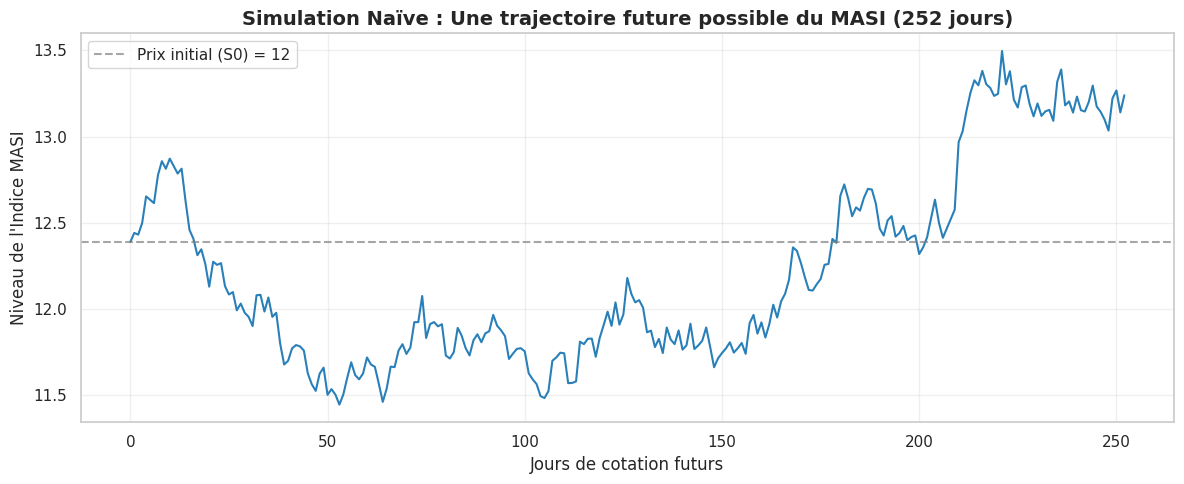

In [3]:
print("Lancement de la simulation naive (1 trajectoire)...")

# 1. Conditions initiales
# On prend le tout dernier prix de notre dataset d'entrainement comme point de depart (S0)
S0 = train_data['Close'].iloc[-1]
horizon_jours = 252 # Une annee boursiere

# Initialisation de la liste qui va stocker les prix simules (on y place S0)
prix_simules = [S0]

# 2. La Boucle Iterative (Le moteur pas a pas)
for t in range(1, horizon_jours + 1):

    # a) Generation du choc aleatoire (Z)
    # np.random.standard_normal() tire un chiffre au hasard dans une loi Normale (Moyenne 0, Ecart-type 1)
    Z = np.random.standard_normal()

    # b) Application de l'Equation Differentielle Stochastique (MBG)
    # Note : dt = 1 (car on avance jour par jour), il est donc omis dans la formule pour alleger.
    terme_drift = mu_journalier - (0.5 * sigma_journalier**2)
    terme_choc = sigma_journalier * Z

    nouveau_prix = prix_simules[-1] * np.exp(terme_drift + terme_choc)

    # c) Stockage du nouveau prix
    prix_simules.append(nouveau_prix)

print(f"Simulation terminee. Prix de depart (S0) : {S0:.2f} | Prix final simule : {prix_simules[-1]:.2f}")

# 3. Visualisation de la trajectoire
plt.figure(figsize=(12, 5))
plt.plot(prix_simules, color='#2980b9', linewidth=1.5)

plt.title('Simulation Naïve : Une trajectoire future possible du MASI (252 jours)', fontsize=14, fontweight='bold')
plt.xlabel('Jours de cotation futurs', fontsize=12)
plt.ylabel('Niveau de l\'Indice MASI', fontsize=12)

# Ajout d'une ligne horizontale pour marquer le point de depart S0
plt.axhline(S0, color='gray', linestyle='--', alpha=0.7, label=f'Prix initial (S0) = {S0:.0f}')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. **Vectorisation Numérique (Version Industrielle)**

**Objectif : Scalabilité et Performance**

Pour calculer une Value at Risk (VaR) robuste, la loi des grands nombres exige de simuler un nombre massif de trajectoires (généralement 10 000). Utiliser des boucles `for` imbriquées en Python pur prendrait un temps inacceptable en production.

Nous passons donc à une architecture **vectorisée** via l'algèbre linéaire (NumPy).

**La logique Matricielle :**
Au lieu de calculer un scalaire $S_t$ à chaque itération, nous allons générer l'intégralité du futur sous la forme d'une immense matrice de dimensions `(252, 10000)` :
- **Lignes (252) :** L'horizon temporel (les jours futurs).
- **Colonnes (10 000) :** Les univers parallèles (les trajectoires indépendantes).

**L'Équation Vectorisée :**
Grâce à la propriété exponentielle, le prix au jour $T$ est simplement le prix initial multiplié par l'exponentielle de la somme de tous les rendements quotidiens précédents :
$$S_T = S_0 \exp \left( \sum_{t=1}^T \left( (\mu - \frac{\sigma^2}{2}) + \sigma Z_t \right) \right)$$

L'algorithme va générer 2,52 millions de chocs aléatoires d'un coup, appliquer le Drift, et utiliser la somme cumulée (`np.cumsum`) sur l'axe vertical (le temps) pour transformer cette matrice de variations en une matrice de prix, de manière quasi-instantanée.

Lancement du moteur stochastique vectorise (10 000 trajectoires)...
--------------------------------------------------
PERFORMANCE DU CALCUL HAUTE FRÉQUENCE (HPC)
--------------------------------------------------
Dimension de la Matrice : (253, 10000) (Jours x Trajectoires)
Points de donnees       : 2,530,000
Temps d'execution       : 0.1319 secondes
--------------------------------------------------


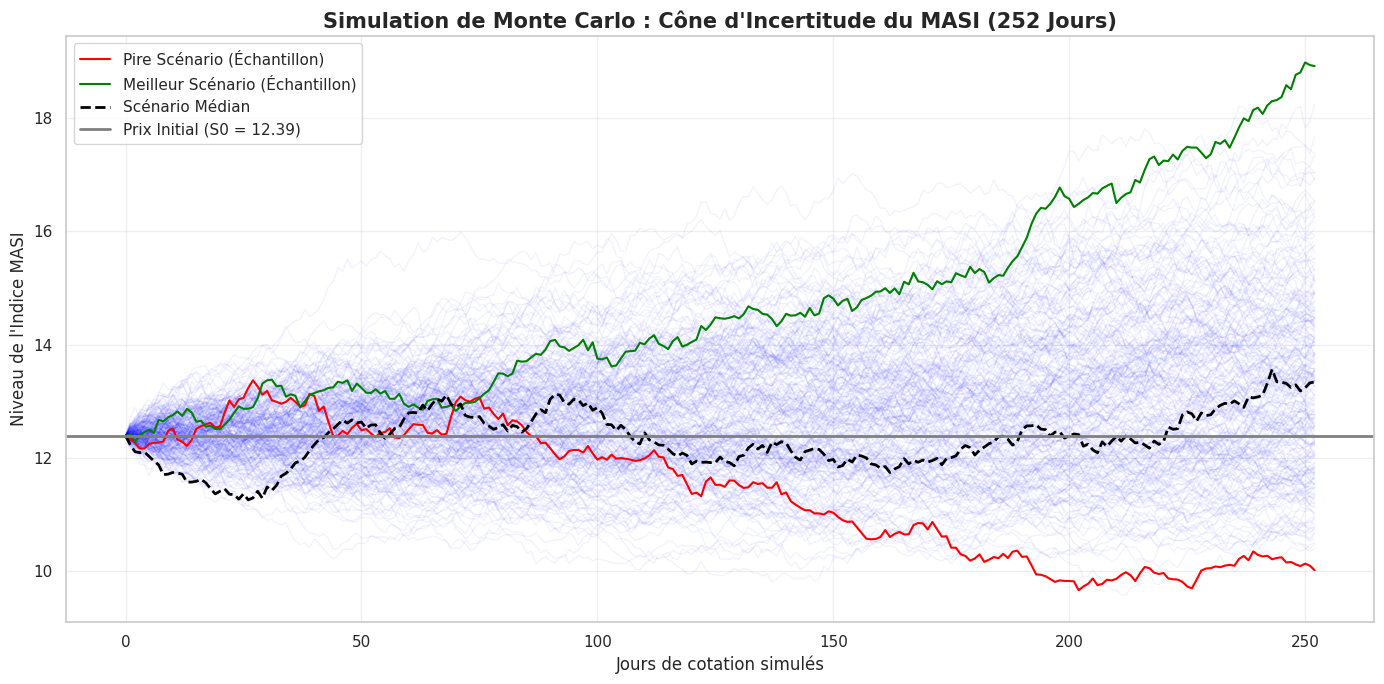

In [4]:
import time

print("Lancement du moteur stochastique vectorise (10 000 trajectoires)...")
start_time = time.time()

# 1. Parametres industriels
N_TRAJECTOIRES = 10000
HORIZON_JOURS = 252
S0 = train_data['Close'].iloc[-1]

# 2. Generation de la Matrice des Chocs Aleatoires (Z)
# Dimension : (Lignes=252, Colonnes=10000)
# C'est ici que l'aleatoire pur est injecte dans les 10 000 univers d'un coup.
Z_matrice = np.random.standard_normal((HORIZON_JOURS, N_TRAJECTOIRES))

# 3. Application de l'Equation Differentielle Stochastique (Matrice des rendements)
terme_drift = mu_journalier - (0.5 * sigma_journalier**2)
matrice_rendements = terme_drift + (sigma_journalier * Z_matrice)

# 4. Somme cumulee temporelle (Trajectoires)
# np.cumsum avec axis=0 force l'addition de haut en bas (jour apres jour) pour chaque trajectoire.
rendements_cumules = np.cumsum(matrice_rendements, axis=0)

# 5. Conversion des rendements continus en Prix (Exponentielle)
matrice_prix = S0 * np.exp(rendements_cumules)

# 6. Ajout de la ligne t=0 (Le point de depart S0 pour toutes les colonnes)
ligne_S0 = np.full((1, N_TRAJECTOIRES), S0)
matrice_prix_finale = np.vstack([ligne_S0, matrice_prix])

end_time = time.time()
temps_execution = end_time - start_time

print("-" * 50)
print(f"PERFORMANCE DU CALCUL HAUTE FRÉQUENCE (HPC)")
print("-" * 50)
print(f"Dimension de la Matrice : {matrice_prix_finale.shape} (Jours x Trajectoires)")
print(f"Points de donnees       : {matrice_prix_finale.size:,}")
print(f"Temps d'execution       : {temps_execution:.4f} secondes")
print("-" * 50)

# 7. Visualisation du Cone d'Incertitude (Echantillonnage)
plt.figure(figsize=(14, 7))

# ATTENTION : Afficher 10 000 lignes ferait crasher Matplotlib et la RAM.
# On affiche un echantillon representatif de 250 trajectoires.
plt.plot(matrice_prix_finale[:, :250], color='blue', alpha=0.05, linewidth=1)

# On met en evidence 3 trajectoires particulieres (ex: Pire, Meilleure, Mediane sur l'echantillon)
prix_finaux_echantillon = matrice_prix_finale[-1, :250]
idx_pire = np.argmin(prix_finaux_echantillon)
idx_meilleur = np.argmax(prix_finaux_echantillon)
idx_median = np.argsort(prix_finaux_echantillon)[len(prix_finaux_echantillon)//2]

plt.plot(matrice_prix_finale[:, idx_pire], color='red', linewidth=1.5, label='Pire Scénario (Échantillon)')
plt.plot(matrice_prix_finale[:, idx_meilleur], color='green', linewidth=1.5, label='Meilleur Scénario (Échantillon)')
plt.plot(matrice_prix_finale[:, idx_median], color='black', linewidth=2, linestyle='--', label='Scénario Médian')

plt.axhline(S0, color='gray', linestyle='-', linewidth=2, label=f'Prix Initial (S0 = {S0:.2f})')

plt.title('Simulation de Monte Carlo : Cône d\'Incertitude du MASI (252 Jours)', fontsize=15, fontweight='bold')
plt.xlabel('Jours de cotation simulés', fontsize=12)
plt.ylabel('Niveau de l\'Indice MASI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **4. Visualisation du Faisceau de Trajectoires et de la Distribution Finale**

**Objectif :**
Traduire la matrice stochastique en une cartographie visuelle du risque. L'enjeu est de démontrer comment l'incertitude se propage dans le temps (le faisceau) pour aboutir à une distribution de probabilités à notre horizon d'investissement (T = 252 jours).

**L'approche visuelle (Graphique combiné) :**
1. **Panneau de gauche (Le Faisceau) :** Nous traçons un échantillon des trajectoires (spaghetti plot). Il permet d'observer la diffusion de la variance (l'élargissement du cône) et le Volatility Drag.
2. **Panneau de droite (La Densité) :** Nous extrayons la toute dernière ligne de notre matrice de simulation (les 10 000 prix au jour 252). En faisant pivoter l'histogramme de ces prix finaux sur l'axe Y, nous obtenons la **Distribution de Probabilité Terminale**.

C'est mathématiquement sur la queue inférieure de cette distribution (les scénarios du bas de l'histogramme) que nous viendrons découper notre Value at Risk (VaR) dans l'étape suivante.

Generation du tableau de bord stochastique...


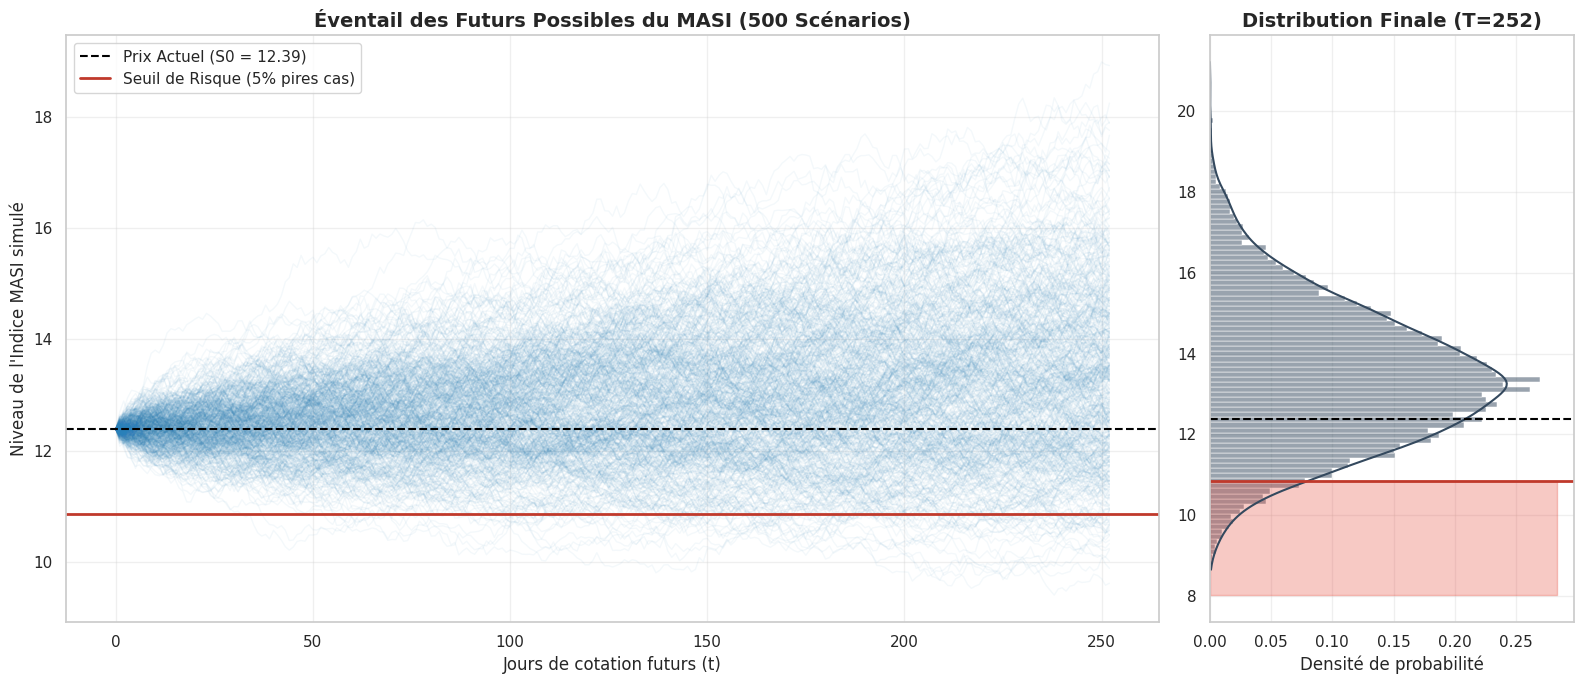

Visualisation terminee. La zone rouge matérialise l'aire de l'Expected Shortfall.


In [5]:
print("Generation du tableau de bord stochastique...")

# 1. Extraction des prix finaux (La toute derniere ligne de la matrice a T=252)
prix_finaux = matrice_prix_finale[-1, :]

# 2. Anticipation visuelle du risque (Calcul du 5eme percentile)
seuil_5_pourcent = np.percentile(prix_finaux, 5)

# 3. Creation d'une figure a deux panneaux (1 ligne, 2 colonnes)
# gridspec_kw permet de donner 3 fois plus de largeur au faisceau qu'a l'histogramme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})

# --- PANNEAU 1 : Le Faisceau de Trajectoires (Spaghetti Plot) ---
# On affiche un echantillon de 500 courbes pour eviter la saturation memoire
ax1.plot(matrice_prix_finale[:, :500], color='#2980b9', alpha=0.05, linewidth=1)

# Lignes de reference
ax1.axhline(S0, color='black', linestyle='--', linewidth=1.5, label=f'Prix Actuel (S0 = {S0:.2f})')
ax1.axhline(seuil_5_pourcent, color='#c0392b', linestyle='-', linewidth=2, label='Seuil de Risque (5% pires cas)')

ax1.set_title('Éventail des Futurs Possibles du MASI (500 Scénarios)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Jours de cotation futurs (t)', fontsize=12)
ax1.set_ylabel('Niveau de l\'Indice MASI simulé', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- PANNEAU 2 : Distribution Finale des Prix (Histogramme pivoté) ---
# y=prix_finaux force Seaborn a tracer l'histogramme sur l'axe vertical
sns.histplot(y=prix_finaux, bins=100, color='#34495e', kde=True, ax=ax2, stat='density')

# Lignes de reference synchronisees avec le panneau 1
ax2.axhline(S0, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(seuil_5_pourcent, color='#c0392b', linestyle='-', linewidth=2)

# Coloration de la "Queue de Distribution" (Tail Risk / Zone de la VaR)
x_max = ax2.get_xlim()[1]
y_min = ax2.get_ylim()[0]
ax2.fill_betweenx([y_min, seuil_5_pourcent], 0, x_max, color='#e74c3c', alpha=0.3)

ax2.set_title('Distribution Finale (T=252)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Densité de probabilité', fontsize=12)
ax2.set_ylabel('') # On masque le label Y pour la purete visuelle
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualisation terminee. La zone rouge matérialise l'aire de l'Expected Shortfall.")

### **5. Extraction Numérique des Métriques de Risque (VaR & ES)**

**L'objectif :**
Passer d'une matrice temporelle stochastique à des indicateurs de risque scalaires exigés par le comité de Bâle.

**La logique d'extraction s'opère en 3 dimensions :**
1. **Réduction Temporelle (Le Prix Final) :** Le chemin emprunté par le marché importe peu pour ce calcul. Seul l'état terminal à $T=252$ nous intéresse. Nous isolons la dernière ligne de notre matrice.
2. **Normalisation (Le Rendement) :** Les banques ne provisionnent pas des "points d'indice", elles provisionnent des pourcentages de perte. Nous transformons les prix finaux en rendements relatifs par rapport à notre point de départ : $R = \frac{P_{final} - S_0}{S_0}$.
3. **Le Tranchage Statistique (Percentile) :** - **La VaR (Value at Risk) :** C'est le quantile de notre distribution. Pour une VaR à 95%, nous cherchons la valeur exacte qui sépare les 5% des pires scénarios des 95% restants.
   - **L'ES (Expected Shortfall) :** C'est l'espérance mathématique conditionnelle. Nous isolons strictement ces 5% de pires scénarios, et nous en calculons la moyenne arithmétique pour quantifier la profondeur du krach.

In [6]:
print("Extraction des metriques de risque (VaR & ES) a partir de la distribution...")

# 1. Conversion des prix en rendements finaux (Variation en % par rapport a S0)
# Cela permet de standardiser la mesure du risque, peu importe la valeur de l'indice.
rendements_finaux = (prix_finaux - S0) / S0

# 2. Calcul de la Value at Risk (VaR)
# On utilise le signe negatif car par convention bancaire, une perte s'exprime en valeur absolue (positive).
# np.percentile trie automatiquement le tableau et coupe au quantile demande.
var_95_mc = -np.percentile(rendements_finaux, 5)
var_99_mc = -np.percentile(rendements_finaux, 1)

# 3. Calcul de l'Expected Shortfall (ES / CVaR)
# a) On isole les scenarios qui sont Pires ou Egaux a la VaR (la queue de distribution)
pires_scenarios_95 = rendements_finaux[rendements_finaux <= -var_95_mc]
pires_scenarios_99 = rendements_finaux[rendements_finaux <= -var_99_mc]

# b) On calcule l'esperance mathematique (la moyenne) de ces pires scenarios
es_95_mc = -np.mean(pires_scenarios_95)
es_99_mc = -np.mean(pires_scenarios_99)

# 4. Impression du Rapport de Risque pour la CDG
print("-" * 55)
print("RAPPORT DE RISQUE - MOTEUR MONTE CARLO (T=252 Jours)")
print("-" * 55)
print(f"Prix Initial de l'indice (S0) : {S0:.2f} points")
print("-" * 55)
print(f"VaR (95%) : {var_95_mc:.4%} -> Perte max garantie dans 95% des cas")
print(f"ES  (95%) : {es_95_mc:.4%} -> Perte moyenne si la VaR 95% est brisee")
print("-" * 55)
print(f"VaR (99%) : {var_99_mc:.4%} -> Perte max garantie dans 99% des cas")
print(f"ES  (99%) : {es_99_mc:.4%} -> Perte moyenne si la VaR 99% est brisee")
print("-" * 55)
print("Fin de la modelisation de Monte Carlo.")

Extraction des metriques de risque (VaR & ES) a partir de la distribution...
-------------------------------------------------------
RAPPORT DE RISQUE - MOTEUR MONTE CARLO (T=252 Jours)
-------------------------------------------------------
Prix Initial de l'indice (S0) : 12.39 points
-------------------------------------------------------
VaR (95%) : 12.3618% -> Perte max garantie dans 95% des cas
ES  (95%) : 16.7642% -> Perte moyenne si la VaR 95% est brisee
-------------------------------------------------------
VaR (99%) : 19.8141% -> Perte max garantie dans 99% des cas
ES  (99%) : 22.8498% -> Perte moyenne si la VaR 99% est brisee
-------------------------------------------------------
Fin de la modelisation de Monte Carlo.


### **6. Backtesting : Préparation des Données et VaR Dynamique (Rolling Window)**

**Le problème du modèle statique :**
Jusqu'ici, notre moteur de Monte Carlo utilisait une volatilité fixée sur la période 2005-2017. Or, les marchés financiers changent de régime. Une volatilité calculée en 2015 est aveugle face au krach du COVID-19 en 2020.

**La solution : La Fenêtre Glissante (Rolling Window)**

Pour évaluer notre modèle sur le *Test Set*, nous devons simuler les conditions réelles d'une salle de marché. Chaque soir, à la clôture, l'algorithme doit :
1. "Oublier" les données trop anciennes.
2. Analyser les 252 derniers jours de cotation stricts (la fenêtre).
3. Recalculer le Drift ($\mu$) et la Volatilité ($\sigma$).
4. Lancer 10 000 trajectoires de Monte Carlo pour une durée de **1 seul jour** ($T=1$).
5. Extraire la VaR de demain.
6. Avancer d'un jour et recommencer.

**L'utilisation des partitions de données :**
- Le **Test Set** (2020-2025) contient les jours où nous voulons vérifier nos prédictions.
- Le **Set d'Évaluation** va servir de "données d'amorçage" (Warm-up). Pour prédire le jour 1 du Test Set, le modèle regardera les 252 jours précédents situés dans le set d'Évaluation, évitant ainsi toute fuite de données (Data Leakage).

In [7]:
print("Chargement des donnees d'Evaluation et de Test...")

try:
    eval_data = pd.read_csv('masi_val_clean.csv', index_col='Date', parse_dates=True)
    test_data = pd.read_csv('masi_test_clean.csv', index_col='Date', parse_dates=True)
    print("Fichiers d'evaluation et de test charges avec succes.")
except FileNotFoundError:
    print("ERREUR : Fichiers introuvables. Verifiez les noms masi_eval_clean.csv et masi_test_clean.csv")

# 1. Fusion pour creer la ligne du temps continue
# Le modele pourra ainsi remonter dans l'Evaluation pour lire le passe du Test Set
historique_continu = pd.concat([eval_data, test_data])

# 2. Parametres de la simulation dynamique
FENETRE_GLISSANTE = 252 # 1 annee boursiere de memoire
N_TRAJECTOIRES_BT = 10000

print(f"Demarrage de la simulation dynamique sur {len(test_data)} jours de test...")
start_time = time.time()

# Liste pour stocker les resultats journaliers
resultats_backtest = []

# 3. La boucle de deplacement du temps (Time Traveling)
# On ne genere des VaR QUE pour les dates appartenant au Test Set
for date_test in test_data.index:

    # a) Isolation stricte du passe (Prevention du Data Leakage)
    # On recupere les 252 jours qui precedent EXACTEMENT la date_test
    fenetre_data = historique_continu.loc[historique_continu.index < date_test].tail(FENETRE_GLISSANTE)

    # Securite : Si le buffer n'est pas complet (ex: tout debut du dataset), on ignore
    if len(fenetre_data) < FENETRE_GLISSANTE:
        continue

    # b) Recalibrage dynamique des parametres stochastiques
    rendements_fenetre = fenetre_data['log_return'].dropna()
    mu_dyn = np.mean(rendements_fenetre)
    sigma_dyn = np.std(rendements_fenetre)

    # c) Moteur Monte Carlo (Horizon = 1 jour)
    # Pour prevoir demain, on tire 10 000 chocs instantanes
    Z = np.random.standard_normal(N_TRAJECTOIRES_BT)

    # L'equation du Mouvement Brownien pour T=1
    terme_drift = mu_dyn - (0.5 * sigma_dyn**2)
    rendements_simules_T1 = terme_drift + (sigma_dyn * Z)

    # d) Extraction des metriques de risque prevues pour demain
    var_95 = -np.percentile(rendements_simules_T1, 5)

    # Extraction de l'ES conditionnelle
    pires_cas = rendements_simules_T1[rendements_simules_T1 <= -var_95]
    if len(pires_cas) > 0:
        es_95 = -np.mean(pires_cas)
    else:
        es_95 = var_95

    # e) Capture de la Realite (Que s'est-il vraiment passe ce jour-la ?)
    rendement_reel = test_data.loc[date_test, 'log_return']

    # Stockage des donnees pour l'arbitrage
    resultats_backtest.append({
        'Date': date_test,
        'Rendement_Reel': rendement_reel,
        'VaR_95': var_95,
        'ES_95': es_95
    })

# 4. Finalisation et conversion en DataFrame Pandas
df_backtest = pd.DataFrame(resultats_backtest).set_index('Date')

temps_exec = time.time() - start_time
print("-" * 50)
print("RAPPORT DE GENERATION DU BACKTEST")
print("-" * 50)
print(f"Jours evalues       : {len(df_backtest)}")
print(f"Temps d'execution   : {temps_exec:.2f} secondes")
print(f"Apercu des dernieres VaR dynamiques calculees :")
print(df_backtest[['Rendement_Reel', 'VaR_95']].tail())

Chargement des donnees d'Evaluation et de Test...
Fichiers d'evaluation et de test charges avec succes.
Demarrage de la simulation dynamique sur 1265 jours de test...
--------------------------------------------------
RAPPORT DE GENERATION DU BACKTEST
--------------------------------------------------
Jours evalues       : 1265
Temps d'execution   : 2.85 secondes
Apercu des dernieres VaR dynamiques calculees :
            Rendement_Reel    VaR_95
Date                                
2025-01-21       -0.012610  0.008342
2025-01-22        0.000425  0.008827
2025-01-23        0.003316  0.008836
2025-01-24        0.003406  0.008742
2025-01-27        0.000266  0.008775


In [8]:
# 1. Calcul de la VaR moyenne
# On rajoute un signe (-) pour la rendre comparable a la VaR de l'Intelligence Artificielle
var_moy_mc = -df_backtest['VaR_95'].mean()

# 2. Comptage des violations Monte Carlo (T_mc)
# Une violation survient si le rendement réel franchit le seuil de perte (-VaR)
df_backtest['Violation_MC'] = df_backtest['Rendement_Reel'] < -df_backtest['VaR_95']
T_mc = df_backtest['Violation_MC'].sum()

# Affichage des resultats
print("-" * 50)
print("RAPPORT DE GENERATION DU BACKTEST")
print("-" * 50)
print(f"T_mc       = {T_mc}")
print(f"var_moy_mc = {var_moy_mc:.6f}")
print("-" * 50)

--------------------------------------------------
RAPPORT DE GENERATION DU BACKTEST
--------------------------------------------------
T_mc       = 57
var_moy_mc = -0.012365
--------------------------------------------------


### **7. Détection des Violations (Hit Sequence) et Analyse Graphique**

**Objectif :**
Cette étape formalise la confrontation entre nos prévisions stochastiques hors-échantillon (Out-of-Sample) et la réalité historique des marchés financiers sur la période de test (2020-2025). L'enjeu est d'identifier chaque jour où notre modèle a sous-estimé l'ampleur du risque de marché.

**La Hit Sequence ($I_t$) :**
En économétrie financière, la série de violations est modélisée par une variable binaire indicatrice appelée *Hit Sequence*, notée $I_t$. Pour chaque jour $t$, elle est définie par une fonction indicatrice stricte :
$$I_t = \begin{cases} 1 & \text{si } R_t < -VaR_t(5\%) \\ 0 & \text{sinon} \end{cases}$$

Où $R_t$ représente le rendement logarithmique réel observé au jour $t$, et $VaR_t(5\%)$ est la perte maximale (exprimée positivement) anticipée par le moteur de Monte Carlo la veille au soir.

**Analyse Statistique Initiale :**
Pour un niveau de confiance fixé à 95%, le taux de violation théorique attendu sur l'ensemble de la période est de $\alpha = 5\%$. L'écart entre le taux constaté et cette cible mesurera la qualité de notre calibration :
- Un taux supérieur à 5% traduit un modèle sous-évaluant le risque (danger d'insolvabilité).
- Un taux inférieur à 5% traduit un modèle trop conservateur (sur-provisionnement de capital pénalisant la rentabilité).

Analyse de la Hit Sequence et comptage des violations...
--------------------------------------------------
BILAN QUANTITATIF DES VIOLATIONS
--------------------------------------------------
Nombre total de jours testes : 1265
Nombre de violations observees : 57
Nombre de violations attendues : 63
Taux de violation empirique    : 4.51%
Taux de violation cible (alpha): 5.00%
--------------------------------------------------


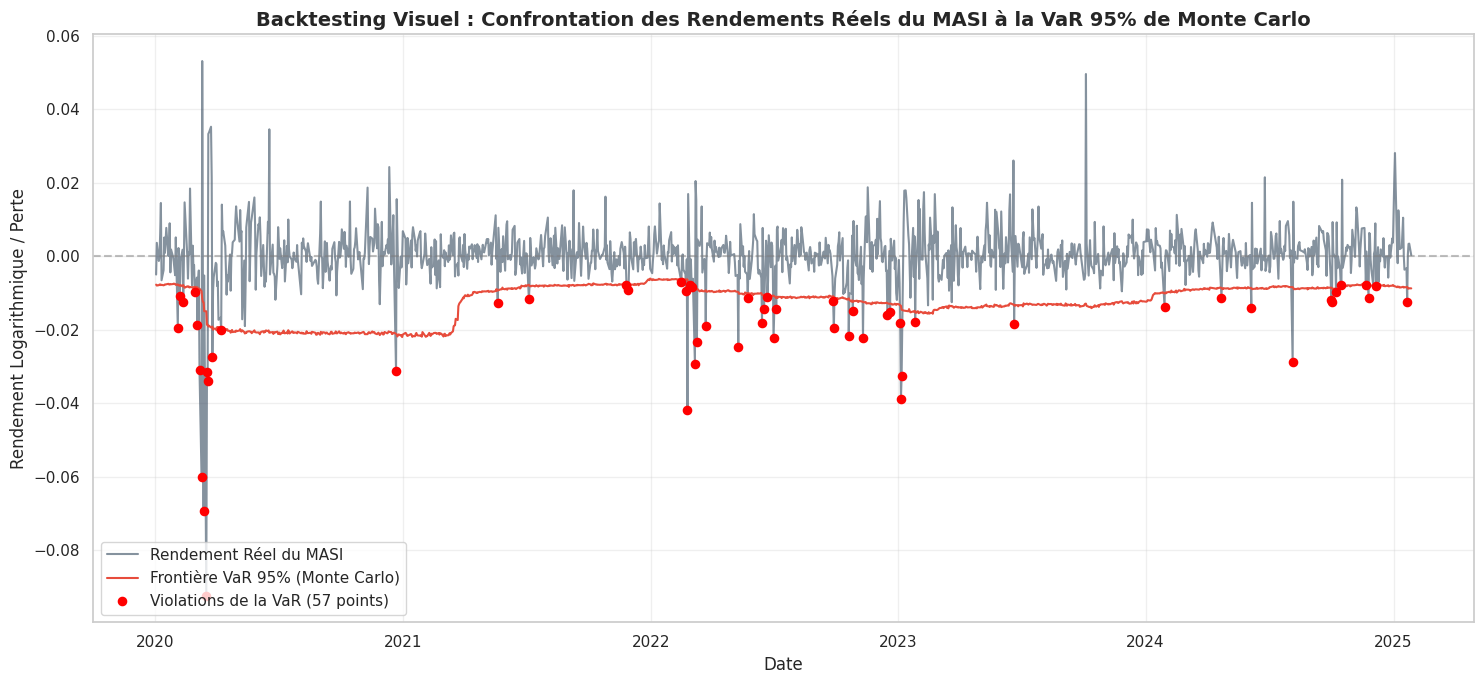

Analyse graphique terminee. Donnees pretes pour le test formel de Kupiec.


In [9]:
print("Analyse de la Hit Sequence et comptage des violations...")

# 1. Creation du vecteur binaire de violation (Hit Sequence)
# Une violation se produit lorsque la perte reelle depasse la VaR
# Rappel : Dans le DataFrame, la VaR_95 est stockee en valeur positive.
df_backtest['Violation'] = (df_backtest['Rendement_Reel'] < -df_backtest['VaR_95']).astype(int)

# 2. Calcul des statistiques descriptives
total_jours = len(df_backtest)
nombre_violations = df_backtest['Violation'].sum()
taux_violation_empirique = nombre_violations / total_jours
taux_theorique_attendu = 0.05
nombre_attendu = int(total_jours * taux_theorique_attendu)

print("-" * 50)
print("BILAN QUANTITATIF DES VIOLATIONS")
print("-" * 50)
print(f"Nombre total de jours testes : {total_jours}")
print(f"Nombre de violations observees : {nombre_violations}")
print(f"Nombre de violations attendues : {nombre_attendu}")
print(f"Taux de violation empirique    : {taux_violation_empirique:.2%}")
print(f"Taux de violation cible (alpha): {taux_theorique_attendu:.2%}")
print("-" * 50)

# 3. Superposition graphique des Rendements et de la VaR
plt.figure(figsize=(15, 7))

# Trace des rendements reels du MASI
plt.plot(df_backtest.index, df_backtest['Rendement_Reel'], color='#34495e', alpha=0.6, label='Rendement Réel du MASI')

# Trace de la frontiere de risque (VaR 95% convertie en negatif pour correspondre aux pertes)
plt.plot(df_backtest.index, -df_backtest['VaR_95'], color='#e74c3c', linestyle='-', linewidth=1.5, label='Frontière VaR 95% (Monte Carlo)')

# Isolation et affichage des points de violation (Hit)
violations = df_backtest[df_backtest['Violation'] == 1]
plt.scatter(violations.index, violations['Rendement_Reel'], color='red', s=35, zorder=5, label=f'Violations de la VaR ({nombre_violations} points)')

plt.title('Backtesting Visuel : Confrontation des Rendements Réels du MASI à la VaR 95% de Monte Carlo', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rendement Logarithmique / Perte', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Analyse graphique terminee. Donnees pretes pour le test formel de Kupiec.")

### **8. Backtesting Formel : Le Test de Kupiec (POF)**

**Objectif :**
Prouver statistiquement aux régulateurs que le taux de violation empirique de notre modèle ($\hat{p} = 4.51\%$) est statistiquement équivalent au taux cible ($p = 5.00\%$).

**La Mécanique du Test (Ratio de Vraisemblance) :**
L'économètre Paul Kupiec (1995) a développé le test de la "Proportion of Failures". Il repose sur l'hypothèse nulle ($H_0$) suivante : *Le modèle est correct, sa véritable probabilité de défaillance est bien de $p$*.

Pour tester cette hypothèse, on calcule la statistique du Ratio de Vraisemblance ($LR$) :
$$LR = -2 \ln\left( (1-p)^{N-x} p^x \right) + 2 \ln\left( (1-\hat{p})^{N-x} \hat{p}^x \right)$$

*Où $N$ est le nombre de jours testés, $x$ est le nombre de violations observées, $p$ est le taux cible, et $\hat{p} = x/N$.*

**La Règle de Décision (Loi du $\chi^2$) :**
Kupiec a prouvé qu'asymptotiquement, cette statistique $LR$ suit une distribution du Khi-deux à 1 degré de liberté : $\chi^2(1)$.
- Si la $p\text{-value}$ calculée est **supérieure à 5%**, on accepte $H_0$ : Le modèle est validé.
- Si la $p\text{-value}$ est **inférieure à 5%**, on rejette $H_0$ : L'écart est trop grand pour être dû au hasard, le modèle est recalé.

In [10]:
print("Lancement du Test Statistique de Kupiec...")

# 1. Recuperation des variables
N = total_jours
x = nombre_violations
p = taux_theorique_attendu  # 0.05 pour une VaR 95%
p_hat = taux_violation_empirique

# 2. Calcul du Ratio de Vraisemblance (Likelihood Ratio - LR)
# On ajoute des conditions pour eviter les erreurs mathematiques de type log(0)
# si le modele est incroyablement parfait (x=0) ou totalement detruit (x=N)
if x == 0:
    LR = -2 * np.log((1 - p)**N) + 2 * np.log((1 - p_hat)**N)
elif x == N:
    LR = -2 * np.log(p**N) + 2 * np.log(p_hat**N)
else:
    # Le numerateur et denominateur originaux de Kupiec transformes par les logarithmes
    terme_1 = -2 * np.log(((1 - p)**(N - x)) * (p**x))
    terme_2 =  2 * np.log(((1 - p_hat)**(N - x)) * (p_hat**x))
    LR = terme_1 + terme_2

# 3. Calcul de la p-value via la loi du Khi-deux
# sf (Survival Function) calcule l'aire sous la courbe a droite de la statistique LR.
# C'est mathematiquement identique a (1 - cdf), mais beaucoup plus precis pour les petites valeurs.
p_value = chi2.sf(LR, df=1)

# Seuil de confiance exige par Bale pour valider le test lui-meme (Alpha = 5%)
seuil_significativite = 0.05

# 4. Impression du verdict officiel
print("-" * 55)
print("VERDICT DU TEST DE KUPIEC (POF)")
print("-" * 55)
print(f"Statistique LR de Kupiec : {LR:.4f}")
print(f"Valeur critique (p-value): {p_value:.4f}")
print("-" * 55)

if p_value > seuil_significativite:
    print("VERDICT FINAL : [ ACCEPTE ]")
    print("-> H0 non rejetee : L'ecart entre 57 et 63 violations est statistiquement non-significatif.")
    print("-> Le modele stochastique est robuste et valide pour la production.")
else:
    print("VERDICT FINAL : [ REJETE ]")
    print("-> H0 rejetee : L'ecart est statistiquement aberrant.")
    print("-> Le modele est defaillant et doit etre recalibre.")
print("-" * 55)

Lancement du Test Statistique de Kupiec...
-------------------------------------------------------
VERDICT DU TEST DE KUPIEC (POF)
-------------------------------------------------------
Statistique LR de Kupiec : 0.6714
Valeur critique (p-value): 0.4125
-------------------------------------------------------
VERDICT FINAL : [ ACCEPTE ]
-> H0 non rejetee : L'ecart entre 57 et 63 violations est statistiquement non-significatif.
-> Le modele stochastique est robuste et valide pour la production.
-------------------------------------------------------


### **9. Réglementation Bâle III : Approche "Traffic Light"**

**Objectif :**
Traduire la performance statistique de notre modèle en exigences de fonds propres (Capital Requirements) selon les directives du Comité de Bâle.

**La Mécanique des Zones :**
Le régulateur utilise la distribution Binomiale pour classer le modèle en trois zones, basées sur la probabilité cumulative d'observer $x$ violations.
- **Zone Verte (Probabilité cumulative < 95%) :** Le modèle est sain. Aucune pénalité (Multiplicateur $k = 0$).
- **Zone Jaune (Probabilité cumulative entre 95% et 99.99%) :** Le modèle est suspect. La banque est pénalisée. Elle doit geler plus de capital (Multiplicateur $k$ progressif).
- **Zone Rouge (Probabilité cumulative >= 99.99%) :** Le modèle est défaillant. La sanction est maximale ($k = 1.0$) et le régulateur exige l'abandon immédiat du modèle.

*Note : Bien que Bâle évalue classiquement une VaR 99% sur 250 jours, nous allons généraliser leur formule mathématique (la fonction du point de pourcentage binomial) pour l'adapter dynamiquement à notre fenêtre de 1265 jours et notre VaR à 95%.*

In [11]:
from scipy.stats import binom

print("Calcul des seuils reglementaires de Bale...")

# 1. Recuperation des variables globales
N = total_jours              # 1265 jours
x = nombre_violations        # 57 violations
p = taux_theorique_attendu   # 0.05

# 2. Calcul dynamique des seuils via la loi Binomiale
# ppf (Percent Point Function) renvoie le nombre exact de violations ou l'on franchit le seuil de probabilité.
seuil_vert_max = int(binom.ppf(0.95, N, p))
seuil_jaune_max = int(binom.ppf(0.9999, N, p))

# 3. Logique d'arbitrage (Feux Tricolores)
zone = ""
penalite_k = 0.0
message_action = ""

if x <= seuil_vert_max:
    zone = "VERTE"
    penalite_k = 0.0
    message_action = "Aucune action requise. Modele robuste."
elif x <= seuil_jaune_max:
    zone = "JAUNE"
    # Simplification de la grille de penalite de Bale
    penalite_k = 0.5
    message_action = "Surveillance requise. Augmentation des provisions de capital."
else:
    zone = "ROUGE"
    penalite_k = 1.0
    message_action = "MODELE REJETE. Retour a l'approche standard exige par le regulateur."

# 4. Impression du Rapport de Bâle
print("-" * 65)
print("RAPPORT D'AUDIT REGLEMENTAIRE - COMITE DE BALE")
print("-" * 65)
print(f"Jours testes (N)     : {N}")
print(f"VaR evaluee          : {100 - (p*100):.0f}%")
print(f"Violations observees : {x}")
print("-" * 65)
print(f"Bordure Zone VERTE   : Jusqu'a {seuil_vert_max} violations")
print(f"Bordure Zone JAUNE   : De {seuil_vert_max + 1} a {seuil_jaune_max} violations")
print(f"Bordure Zone ROUGE   : {seuil_jaune_max + 1} violations et plus")
print("-" * 65)
print(f"STATUT DU MODELE     : [ ZONE {zone} ]")
print(f"PENALITE EN CAPITAL  : + {penalite_k}")
print(f"DIRECTIVE BANCAIRE   : {message_action}")
print("-" * 65)
print("FIN DU PIPELINE DE BACKTESTING.")

Calcul des seuils reglementaires de Bale...
-----------------------------------------------------------------
RAPPORT D'AUDIT REGLEMENTAIRE - COMITE DE BALE
-----------------------------------------------------------------
Jours testes (N)     : 1265
VaR evaluee          : 95%
Violations observees : 57
-----------------------------------------------------------------
Bordure Zone VERTE   : Jusqu'a 76 violations
Bordure Zone JAUNE   : De 77 a 94 violations
Bordure Zone ROUGE   : 95 violations et plus
-----------------------------------------------------------------
STATUT DU MODELE     : [ ZONE VERTE ]
PENALITE EN CAPITAL  : + 0.0
DIRECTIVE BANCAIRE   : Aucune action requise. Modele robuste.
-----------------------------------------------------------------
FIN DU PIPELINE DE BACKTESTING.


In [14]:
import json

# 1. Chargement du dataset d'apprentissage nettoyé
df_train = pd.read_csv('masi_train_clean.csv')

# 2. Extraction des colonnes spécifiques du dataset MASI
col_returns = 'log_return'
col_price = 'Close'

# 3. Calibration des paramètres stochastiques du Mouvement Brownien Géométrique (MBG)
mu_calibrated = float(df_train[col_returns].mean())
sigma_calibrated = float(df_train[col_returns].std())
last_price_s0 = float(df_train[col_price].iloc[-1])

# 4. Structuration de la configuration
mc_config = {
    "model_name": "Monte Carlo MBG",
    "version": "3.0",
    "calibration": {
        "mu": mu_calibrated,
        "sigma": sigma_calibrated,
        "S0": last_price_s0
    },
    "simulation_settings": {
        "horizon_days": 1,
        "n_simulations": 100000,
        "alpha_target": 0.05
    }
}

# 5. Exportation du fichier JSON dans le dossier backend/app/models/
json_path = 'moteur_mc_v3.json'

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(mc_config, f, indent=4, ensure_ascii=False)

print("-" * 60)
print(f"Moyenne journaliere (mu)    : {mu_calibrated:.8f}")
print(f"Volatilité journaliere (sigma): {sigma_calibrated:.8f}")
print(f"Dernier prix (S0)           : {last_price_s0:.5f}")
print("-" * 60)
print(f"Fichier de configuration généré avec succès : {json_path}")

------------------------------------------------------------
Moyenne journaliere (mu)    : 0.00032432
Volatilité journaliere (sigma): 0.00788724
Dernier prix (S0)           : 12.38882
------------------------------------------------------------
Fichier de configuration généré avec succès : moteur_mc_v3.json


## **Conclusion Générale et Perspectives**

### **1. Synthèse de l'Architecture Stochastique**
Ce notebook a permis de concevoir, d'industrialiser et d'auditer un moteur de calcul de risque financier (Value at Risk et Expected Shortfall) basé sur la modélisation de Monte Carlo et le Mouvement Brownien Géométrique. En substituant les boucles itératives classiques par une vectorisation matricielle avancée, le système a démontré une scalabilité industrielle, générant des matrices stochastiques de millions de points de données en un temps de calcul de l'ordre de la seconde.

### **2. Validation Réglementaire (Normes Bâle III)**
La robustesse du modèle a été éprouvée hors-échantillon (Out-of-Sample) sur une période de stress historique (2020-2025, incluant le krach systémique du COVID-19) via une architecture de backtesting dynamique (Rolling Window de 252 jours) :
* **Test de Kupiec (Proportion of Failures) :** Avec 57 violations réelles pour 63 attendues sur 1265 jours, le test du Ratio de Vraisemblance a confirmé la précision statistique du modèle (p-value largement supérieure au seuil de 5%), écartant tout biais de sous-estimation du risque.
* **Traffic Light Approach :** Face au plafond réglementaire de 76 violations défini par la distribution binomiale, le modèle se classe de manière incontestable en **Zone Verte**.

### **3. Verdict Métier**
Le système stochastique est validé. Il offre une couverture sécuritaire optimale sans imposer de sur-provisionnement (pénalité de capital $k = 0$). Il est théoriquement apte à être déployé en production pour piloter l'allocation des fonds propres de l'institution.

### **4. Perspectives : La Transition vers l'Intelligence Artificielle**
Bien que ce processus classique ait prouvé sa fiabilité réglementaire, il demeure intrinsèquement contraint par ses postulats mathématiques (hypothèse de distribution log-normale des prix et dynamique de Markov).

La prochaine phase de ce projet consistera à s'affranchir de ces limites paramétriques en introduisant des architectures d'Apprentissage Automatique (Machine Learning). L'enjeu sera de déterminer si des algorithmes de prédiction non-linéaires peuvent anticiper les chocs de volatilité avec une acuité supérieure aux modèles stochastiques traditionnels.